# Repetition Lag-CRP

> Compute and visualize lag-CRP separately for each presentation of repeated items.

The repetition Lag-CRP extends the standard Lag-CRP analysis to study lists containing repeated items. For each recall of a repeated item, the analysis separately tabulates lag transitions relative to each of the item's study positions. This produces one CRP curve per presentation index, revealing whether transitions from repeated items cluster around the first or second occurrence.

Comparing repetition CRP curves between observed data and shuffled controls helps isolate repetition-specific effects from baseline temporal contiguity [@lohnas2014retrieved].

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `control_trial_query` | Query string selecting pure (control) trials |
| `control_shuffles` | Number of shuffled control blocks per subject |
| `min_lag` | Minimum spacing between repeated occurrences |
| `max_lag` | Maximum lag to display |
| `size` | Maximum presentations per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.repcrp import (
    RepCRPTabulation,
    plot_difference_rep_crp,
    plot_first_rep_crp,
    plot_rep_crp,
    plot_second_rep_crp,
    repcrp,
    subject_rep_crp,
    tabulate_trial,
    test_first_second_bias,
    test_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] > 2'
control_trial_query = 'data["list_type"] == 1'
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

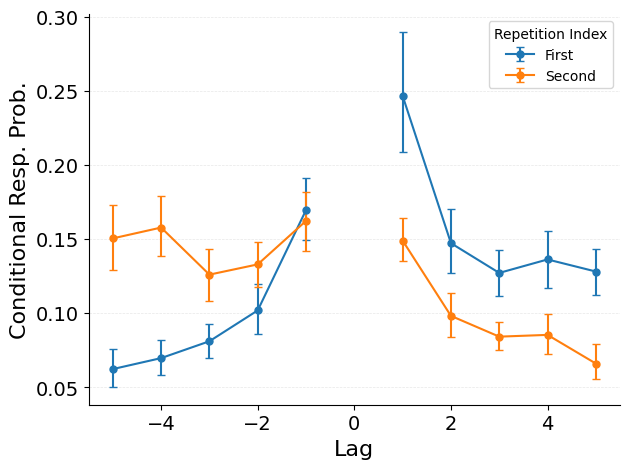

In [5]:
#| code-summary: Plot repetition Lag-CRP (observed)
#| label: fig-repcrp
#| fig-cap: "Repetition Lag-CRP for each presentation index of repeated items."
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

---

## Reference

### Plotting

`plot_rep_crp` draws one CRP line per repetition index. Convenience wrappers `plot_first_rep_crp` and `plot_second_rep_crp` select a single index, while `plot_difference_rep_crp` plots the first-minus-second difference.

In [6]:
#| echo: false
show_doc(plot_rep_crp)

---

### plot_rep_crp

>      plot_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr
>                    .typing.RecallDataset], trial_masks:Union[Sequence[jaxtypin
>                    g.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial_co
>                    unt']], max_lag:int=5, min_lag:int=4, size:int=2,
>                    repetition_index:Optional[int]=None,
>                    color_cycle:Optional[list[str]]=None,
>                    labels:Optional[Sequence[str]]=None,
>                    contrast_name:Optional[str]=None,
>                    axis:Optional[matplotlib.axes._axes.Axes]=None,
>                    confidence_level:float=0.95)

*Plot repetition Lag-CRP with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| max_lag | int | 5 | Maximum lag to display. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| repetition_index | Optional | None | Plot only this repetition index. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for repetition-index lines. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the repetition Lag-CRP plot.** |

In [7]:
#| echo: false
show_doc(plot_first_rep_crp)

---

### plot_first_rep_crp

>      plot_first_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],
>                          jaxcmr.typing.RecallDataset], trial_masks:Union[Seque
>                          nce[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bo
>                          ol[Array,'trial_count']], max_lag:int=5,
>                          min_lag:int=4, size:int=2,
>                          color_cycle:Optional[list[str]]=None,
>                          labels:Optional[Sequence[str]]=None,
>                          contrast_name:Optional[str]=None,
>                          axis:Optional[matplotlib.axes._axes.Axes]=None,
>                          confidence_level:float=0.95)

*Convenience function to plot first repetition CRP.*

In [8]:
#| echo: false
show_doc(plot_second_rep_crp)

---

### plot_second_rep_crp

>      plot_second_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset]
>                           ,jaxcmr.typing.RecallDataset], trial_masks:Union[Seq
>                           uence[jaxtyping.Bool[Array,'trial_count']],jaxtyping
>                           .Bool[Array,'trial_count']], max_lag:int=5,
>                           min_lag:int=4, size:int=2,
>                           color_cycle:Optional[list[str]]=None,
>                           labels:Optional[Sequence[str]]=None,
>                           contrast_name:Optional[str]=None,
>                           axis:Optional[matplotlib.axes._axes.Axes]=None,
>                           confidence_level:float=0.95)

*Convenience function to plot second repetition CRP.*

In [9]:
#| echo: false
show_doc(plot_difference_rep_crp)

---

### plot_difference_rep_crp

>      plot_difference_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallData
>                               set],jaxcmr.typing.RecallDataset], trial_masks:U
>                               nion[Sequence[jaxtyping.Bool[Array,'trial_count'
>                               ]],jaxtyping.Bool[Array,'trial_count']],
>                               max_lag:int=5, min_lag:int=4, size:int=2,
>                               color_cycle:Optional[list[str]]=None,
>                               labels:Optional[Sequence[str]]=None,
>                               contrast_name:Optional[str]=None,
>                               axis:Optional[matplotlib.axes._axes.Axes]=None,
>                               confidence_level:float=0.95)

*Plot difference between first and second presentation CRPs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| max_lag | int | 5 | Maximum lag to display. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the difference CRP plot.** |

### Computation

In [10]:
#| echo: false
show_doc(repcrp)

---

### repcrp

>      repcrp (dataset:jaxcmr.typing.RecallDataset, min_lag:int=4, size:int=2)

*Lag-CRP centered on each presentation of repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of shape ``(size, 2*L - 1)`` per repetition index.** |

In [11]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      min_lag:int=4, size:int=2)

*Tabulate observed and available lags for a trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall events for a single trial. |
| presentation | Integer[Array, 'study_events'] |  | Study events for the trial. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| size | int | 2 | Maximum positions an item can occupy. |
| **Returns** | **tuple** |  | **Actual and available lag tabulations.** |

In [12]:
#| echo: false
show_doc(subject_rep_crp)

---

### subject_rep_crp

>      subject_rep_crp (dataset:jaxcmr.typing.RecallDataset,
>                       trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                       min_lag:int=4, max_lag:int=5, size:int=2)

*Compute subject-level repetition CRP values.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| max_lag | int | 5 | Maximum lag to include in output. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  | **Shape ``(n_subjects, size, 2*max_lag+1)``.** |

### Statistical Tests

`test_rep_crp_vs_control` compares observed and control CRP at each lag per presentation. `test_first_second_bias` tests whether the first-presentation advantage differs from what the control predicts.

In [13]:
#| echo: false
show_doc(test_rep_crp_vs_control)

---

### test_rep_crp_vs_control

>      test_rep_crp_vs_control (observed_crp:numpy.ndarray,
>                               control_crp:numpy.ndarray, max_lag:int=5)

*Test observed vs control CRP per presentation index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP, shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level control CRP, same shape. |
| max_lag | int | 5 | Maximum lag (used for labeling). |
| **Returns** | **dict** |  | **Results keyed by presentation label.** |

In [14]:
#| echo: false
show_doc(test_first_second_bias)

---

### test_first_second_bias

>      test_first_second_bias (observed_crp:numpy.ndarray,
>                              control_crp:numpy.ndarray, max_lag:int=5)

*Test whether first-presentation bias differs from control.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP, shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level control CRP, same shape. |
| max_lag | int | 5 | Maximum lag (used for labeling). |
| **Returns** | **RepCRPTestResult** |  | **Test statistics for the difference of differences.** |